# Fraud Detection - Data Mining & Pattern Discovery

This notebook applies unsupervised learning and feature analysis to the merged events dataset.

**Important:** SEON scores (fraud_score, blackbox_score, etc.) are **excluded** from model features since they represent the benchmark we're trying to beat.

**Goals:**
1. Cluster analysis using non-score features to find fraud patterns
2. Feature importance analysis for fraud prediction (without SEON scores)
3. Identify which categorical/boolean features are most predictive
4. Establish baseline model performance without relying on SEON scores

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

DATA_PATH = "../artifacts/merged_events.parquet"

# Display settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 50)

## 1. Load and Prepare Data

In [2]:
print(f"Loading data from {DATA_PATH}...")
df_pl = pl.read_parquet(DATA_PATH)
print(f"Shape: {df_pl.shape[0]:,} rows x {df_pl.shape[1]} columns")

Loading data from ../artifacts/merged_events.parquet...
Shape: 732,589 rows x 230 columns


In [3]:
# Identify feature groups
schema = df_pl.schema

# Score features - EXCLUDED from model features (these are SEON benchmark scores)
score_cols = [c for c in df_pl.columns if "score" in c.lower() and schema[c] in (pl.Float64, pl.Float32, pl.Int64, pl.Int32)]

# Boolean/flag features - these WILL be used as features
bool_cols = [c for c in df_pl.columns if schema[c] == pl.Boolean]

# Categorical features from SEON (non-score) - these WILL be used as features
seon_cat_cols = [c for c in df_pl.columns if c.startswith(("ip_", "phone_", "session/", "email/"))]

# Event features
event_cols = ["STATUS", "FLAGGEDFORFRAUD"]
event_cols = [c for c in event_cols if c in df_pl.columns]

print(f"Score columns ({len(score_cols)}): {score_cols} [EXCLUDED - benchmark only]")
print(f"Boolean columns ({len(bool_cols)}): {bool_cols[:10]}...")
print(f"SEON categorical ({len(seon_cat_cols)}): {seon_cat_cols[:10]}...")

Score columns (6): ['AUTOAPPROVALCRITERIA_META_SEONFRAUDSCORE', 'fraud_score', 'blackbox_score', 'phone_score', 'email_score', 'proxy_score'] [EXCLUDED - benchmark only]
Boolean columns (44): ['AUTOAPPROVALCRITERIA_CRITERIA_HASUSEDSAMEEMAILBEFORE', 'AUTOAPPROVALCRITERIA_CRITERIA_SEONAPPROVED', 'FLAGGEDFORFAKECHECK', 'LISTING_CHARACTERISTICS_AREPETSALLOWED', 'LISTING_CHARACTERISTICS_HASBALCONY', 'LISTING_CHARACTERISTICS_HASBUILDINGLAWRESTRICTIONS', 'LISTING_CHARACTERISTICS_HASCABLETV', 'LISTING_CHARACTERISTICS_HASDISHWASHER', 'LISTING_CHARACTERISTICS_HASELEVATOR', 'LISTING_CHARACTERISTICS_HASFIREPLACE']...
SEON categorical (16): ['phone_score', 'ip_type', 'ip_country', 'ip_isp_name', 'email/domain/disposable', 'email/domain/free', 'email/deliverable', 'email/haveibeenpwned_listed', 'phone_type', 'phone_country']...


In [4]:
# Target column
TARGET_COL = "is_fraud"

if TARGET_COL not in df_pl.columns:
    # Derive from FLAGGEDFORFRAUD if needed
    if "FLAGGEDFORFRAUD" in df_pl.columns:
        df_pl = df_pl.with_columns(
            pl.col("FLAGGEDFORFRAUD").is_not_null().cast(pl.Int8).alias(TARGET_COL)
        )
    else:
        raise ValueError("Cannot find or derive target column")

print(f"\nTarget: {TARGET_COL}")
print(f"Fraud Rate: {df_pl[TARGET_COL].mean():.4%}")


Target: is_fraud
Fraud Rate: 0.9535%


In [5]:
# Sample for faster processing
SAMPLE_SIZE = 100000

if df_pl.height > SAMPLE_SIZE:
    print(f"Sampling {SAMPLE_SIZE:,} rows for analysis...")
    # Stratified-like sampling: ensure fraud cases are included
    fraud_df = df_pl.filter(pl.col(TARGET_COL) == 1)
    non_fraud_df = df_pl.filter(pl.col(TARGET_COL) == 0)
    
    n_fraud = min(fraud_df.height, SAMPLE_SIZE // 10)  # 10% fraud in sample
    n_non_fraud = SAMPLE_SIZE - n_fraud
    
    df_sample = pl.concat([
        fraud_df.sample(n_fraud, seed=42),
        non_fraud_df.sample(min(n_non_fraud, non_fraud_df.height), seed=42)
    ]).sample(fraction=1.0, seed=42)  # Shuffle
    
    print(f"Sample fraud rate: {df_sample[TARGET_COL].mean():.2%}")
else:
    df_sample = df_pl

print(f"Sample size: {df_sample.height:,}")

Sampling 100,000 rows for analysis...
Sample fraud rate: 6.98%
Sample size: 100,000


## 2. Feature Preparation for Mining

In [ ]:
# Prepare features for clustering and analysis
# EXCLUDING: SEON scores, AUTOAPPROVALCRITERIA_CRITERIA*, FLAGGEDFORFAKECHECK

# Columns to exclude (benchmark/system-generated/IDs)
excluded_patterns = [
    "score", "AUTOAPPROVALCRITERIA_CRITERIA", "FLAGGEDFORFAKECHECK",
    "ID", "_id", "TIMESTAMP", "UUID"  # ID and timestamp columns
]
excluded_cols = score_cols + [
    c for c in df_sample.columns 
    if any(p in c for p in ["AUTOAPPROVALCRITERIA_CRITERIA", "FLAGGEDFORFAKECHECK"])
]

print("NOTE: The following patterns are EXCLUDED from features:")
print(f"  {excluded_patterns}")

# Helper to check if column should be excluded
def should_exclude(col_name):
    return any(p in col_name for p in excluded_patterns)

# Boolean features as numeric (high coverage, excluding system-generated)
bool_as_numeric = [
    c for c in bool_cols 
    if c in df_sample.columns 
    and df_sample[c].null_count() < df_sample.height * 0.5
    and not should_exclude(c)
]

# Numeric features (excluding scores and system-generated)
numeric_types = (pl.Float64, pl.Float32, pl.Int64, pl.Int32)
numeric_cols = [
    c for c in df_sample.columns 
    if schema[c] in numeric_types 
    and c not in excluded_cols
    and not should_exclude(c)
    and c != "is_fraud"
    and c != "seon_tx_id"
    and df_sample[c].null_count() < df_sample.height * 0.5
][:30]

print(f"\nBoolean columns: {len(bool_as_numeric)}")
print(f"Numeric columns: {len(numeric_cols)}")

feature_cols = bool_as_numeric + numeric_cols
print(f"\nTotal features for mining: {len(feature_cols)}")

NOTE: SEON scores are EXCLUDED from features - they represent the benchmark we want to beat.
Excluded score columns: ['AUTOAPPROVALCRITERIA_META_SEONFRAUDSCORE', 'fraud_score', 'blackbox_score', 'phone_score', 'email_score', 'proxy_score']

Boolean columns: 14
Numeric columns (non-score): 17

Total features for mining: 31


In [7]:
# Prepare feature matrix
df_features = df_sample.select(feature_cols + [TARGET_COL]).to_pandas()

# Convert booleans to int
for col in df_features.columns:
    if df_features[col].dtype == 'bool' or df_features[col].dtype == 'object':
        df_features[col] = df_features[col].astype(float)

# Handle missing values and infinities
X = df_features[feature_cols].fillna(0)
X = X.replace([np.inf, -np.inf], 0)

y = df_features[TARGET_COL].fillna(0).astype(int)

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")

Feature matrix shape: (100000, 31)
Target shape: (100000,)
Target distribution: {0: 93015, 1: 6985}


In [8]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled successfully.")

Features scaled successfully.


## 3. K-Means Clustering

Running K-Means elbow analysis...
  K=2: Inertia=2707477
  K=3: Inertia=2593040
  K=4: Inertia=2491262
  K=5: Inertia=2394772
  K=6: Inertia=2294515
  K=7: Inertia=2239259
  K=8: Inertia=2131207
  K=9: Inertia=2034695
  K=10: Inertia=1944431
  K=11: Inertia=1897843


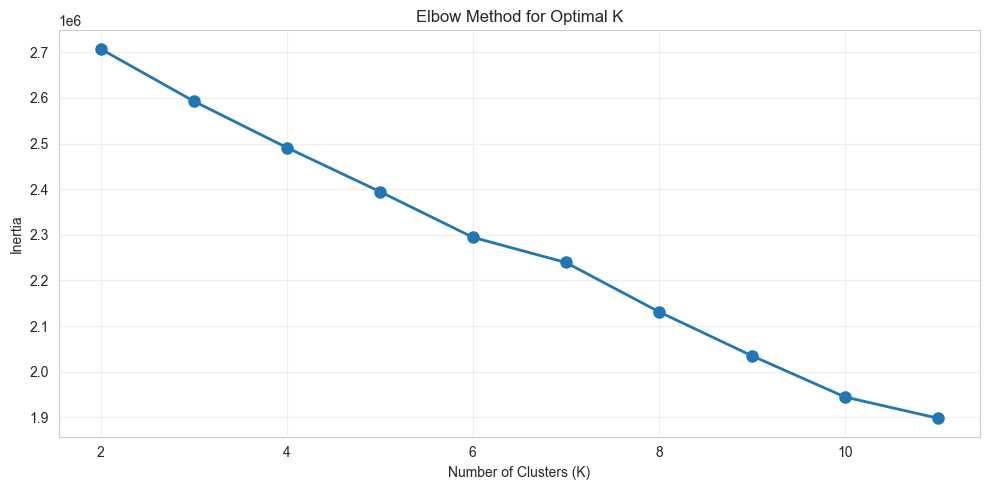

In [9]:
# Elbow method to find optimal K
print("Running K-Means elbow analysis...")

inertias = []
k_range = range(2, 12)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f"  K={k}: Inertia={kmeans.inertia_:.0f}")

# Plot elbow curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(k_range), inertias, marker='o', linewidth=2, markersize=8)
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow Method for Optimal K")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Fit K-Means with chosen K
OPTIMAL_K = 5

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10, max_iter=300)
clusters = kmeans.fit_predict(X_scaled)

df_features["cluster"] = clusters

print(f"\nCluster Distribution:")
print(df_features["cluster"].value_counts().sort_index())


Cluster Distribution:
cluster
0     5674
1    38144
2    31619
3      666
4    23897
Name: count, dtype: int64



Fraud Rate by Cluster:
         count  fraud_count  fraud_rate
cluster                                
3          666          451      0.6772
4        23897         4539      0.1899
0         5674          799      0.1408
1        38144          991      0.0260
2        31619          205      0.0065


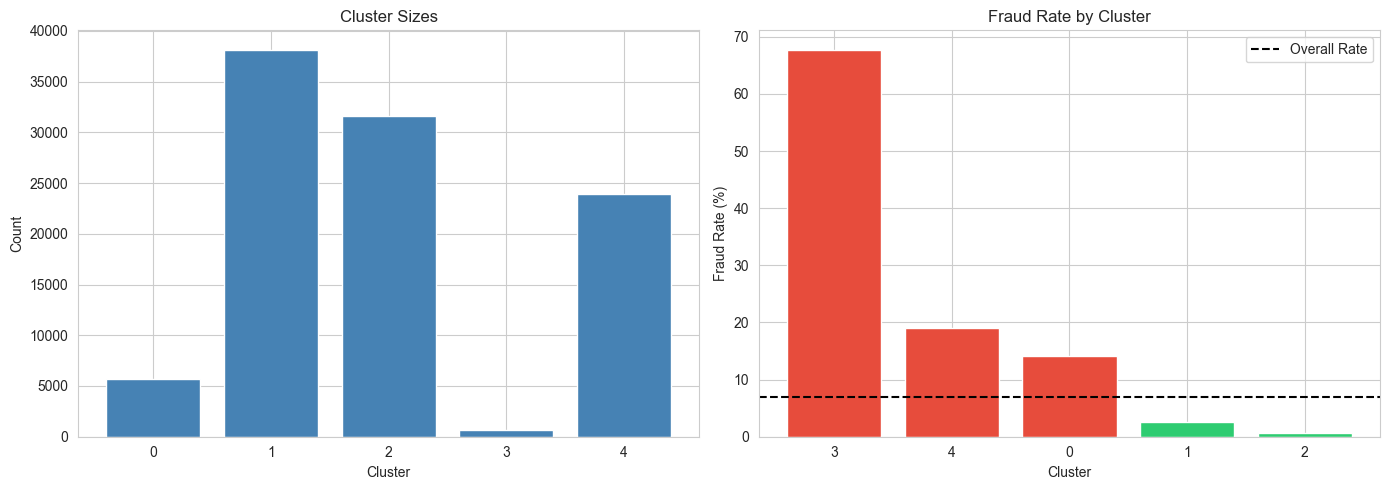

In [11]:
# Analyze fraud rate per cluster
cluster_fraud = df_features.groupby("cluster").agg({
    TARGET_COL: ["count", "sum", "mean"]
}).round(4)

cluster_fraud.columns = ["count", "fraud_count", "fraud_rate"]
cluster_fraud = cluster_fraud.sort_values("fraud_rate", ascending=False)

print("\nFraud Rate by Cluster:")
print(cluster_fraud)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cluster sizes
ax1 = axes[0]
clusters_sorted = cluster_fraud.sort_index()
ax1.bar(clusters_sorted.index.astype(str), clusters_sorted["count"], color="steelblue")
ax1.set_xlabel("Cluster")
ax1.set_ylabel("Count")
ax1.set_title("Cluster Sizes")

# Fraud rates
ax2 = axes[1]
colors = ["#e74c3c" if r > df_features[TARGET_COL].mean() else "#2ecc71" for r in cluster_fraud["fraud_rate"]]
ax2.bar(cluster_fraud.index.astype(str), cluster_fraud["fraud_rate"] * 100, color=colors)
ax2.axhline(y=df_features[TARGET_COL].mean() * 100, color="black", linestyle="--", label="Overall Rate")
ax2.set_xlabel("Cluster")
ax2.set_ylabel("Fraud Rate (%)")
ax2.set_title("Fraud Rate by Cluster")
ax2.legend()

plt.tight_layout()
plt.show()

In [12]:
# Cluster centroids analysis
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=feature_cols
)
centroids.index.name = "cluster"

# Show top varying features for each cluster
print("\nCluster Centroids (Top Features):")
# Show first 10 feature columns
display_cols = feature_cols[:10]
print(centroids[display_cols].round(3))


Cluster Centroids (Top Features):
         AUTOAPPROVALCRITERIA_CRITERIA_HASUSEDSAMEEMAILBEFORE  \
cluster                                                         
0                                                    0.284      
1                                                    0.324      
2                                                    0.715      
3                                                    0.033      
4                                                    0.055      

         AUTOAPPROVALCRITERIA_CRITERIA_SEONAPPROVED  FLAGGEDFORFAKECHECK  \
cluster                                                                    
0                                             0.649                  0.0   
1                                             0.954                  0.0   
2                                             0.922                  0.0   
3                                             0.035                  0.0   
4                                             0.132  

## 4. Feature Importance Analysis

In [13]:
# Random Forest feature importance
print("Training Random Forest for feature importance...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

print("\nRandom Forest Performance:")
print(classification_report(y_test, y_pred, target_names=["Non-Fraud", "Fraud"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

Training Random Forest for feature importance...

Random Forest Performance:
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.91      0.95     18603
       Fraud       0.42      0.91      0.57      1397

    accuracy                           0.91     20000
   macro avg       0.71      0.91      0.76     20000
weighted avg       0.95      0.91      0.92     20000

ROC-AUC: 0.9541



Top 20 Most Important Features:
                                              feature  importance
1          AUTOAPPROVALCRITERIA_CRITERIA_SEONAPPROVED    0.227571
23                         LISTING_LEGACY_PPAPERSONID    0.100681
22                            LISTING_LEGACY_PERSONID    0.090114
27                                            VERSION    0.085900
10                        email/haveibeenpwned_listed    0.060313
20              LISTING_CHARACTERISTICS_NUMBEROFROOMS    0.055947
14                                          LISTINGID    0.051196
15                          LISTING_PRICES_RENT_GROSS    0.044957
18                LISTING_CHARACTERISTICS_LIVINGSPACE    0.038394
25                        SELECTEDBUNDLE_INITIALPRICE    0.035893
0   AUTOAPPROVALCRITERIA_CRITERIA_HASUSEDSAMEEMAIL...    0.035786
26                      SELECTEDBUNDLE_RECURRINGPRICE    0.032311
30      DATAPIPELINE_SQSMETA_ATTRIBUTES_SENTTIMESTAMP    0.029376
28  DATAPIPELINE_SQSMETA_ATTRIBUTES_APPROXI

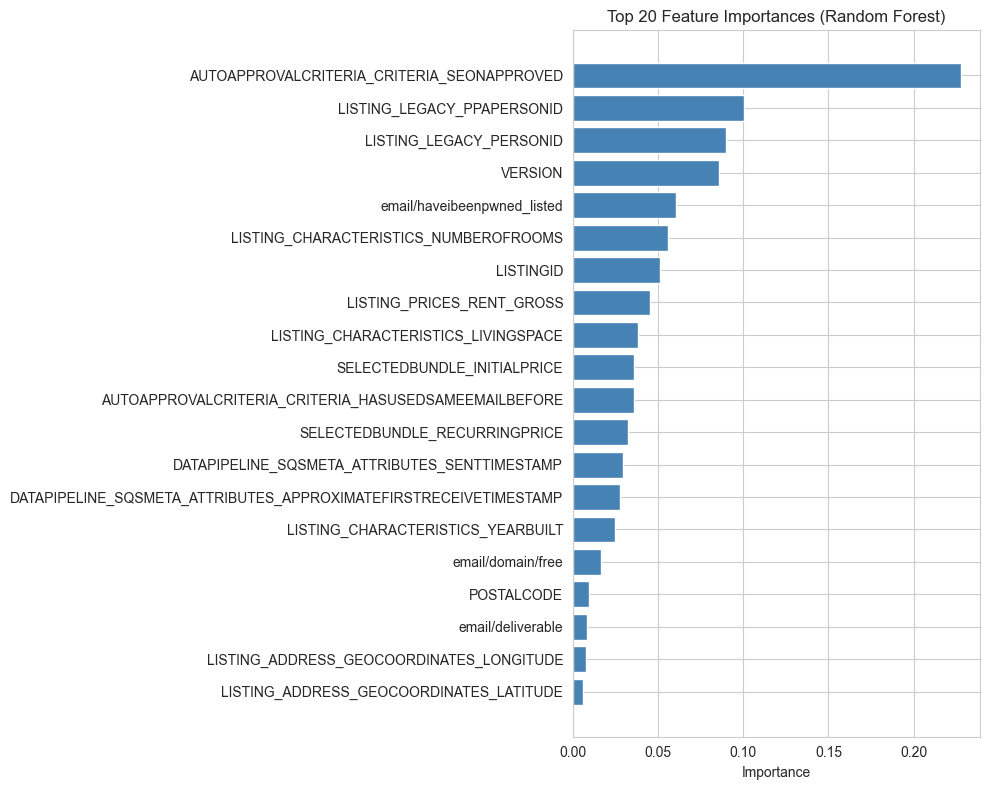

In [14]:
# Feature importance rankings
importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 20 Most Important Features:")
print(importances.head(20))

# Visualize top features
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 20
top_features = importances.head(top_n)

ax.barh(top_features["feature"][::-1], top_features["importance"][::-1], color="steelblue")
ax.set_xlabel("Importance")
ax.set_title(f"Top {top_n} Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

In [15]:
# Logistic Regression coefficients (for interpretability)
print("Training Logistic Regression for coefficient analysis...")

lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced",
    solver="lbfgs"
)

lr.fit(X_train, y_train)

# Coefficients
coefficients = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lr.coef_[0],
    "abs_coef": np.abs(lr.coef_[0])
}).sort_values("abs_coef", ascending=False)

print("\nTop 20 Features by Logistic Regression Coefficient:")
print(coefficients.head(20))

# Evaluate
y_pred_lr = lr.predict(X_test)
y_pred_proba_lr = lr.predict_proba(X_test)[:, 1]

print(f"\nLogistic Regression ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

Training Logistic Regression for coefficient analysis...

Top 20 Features by Logistic Regression Coefficient:
                                              feature   coefficient  \
14                                          LISTINGID -3.363986e-10   
28  DATAPIPELINE_SQSMETA_ATTRIBUTES_APPROXIMATEFIR... -1.242333e-13   
30      DATAPIPELINE_SQSMETA_ATTRIBUTES_SENTTIMESTAMP -1.242333e-13   
15                          LISTING_PRICES_RENT_GROSS  3.953097e-15   
24                                         POSTALCODE -1.368115e-15   
23                         LISTING_LEGACY_PPAPERSONID  4.022847e-16   
22                            LISTING_LEGACY_PERSONID  4.022847e-16   
21                  LISTING_CHARACTERISTICS_YEARBUILT -1.420514e-16   
18                LISTING_CHARACTERISTICS_LIVINGSPACE -4.694697e-17   
25                        SELECTEDBUNDLE_INITIALPRICE  2.412401e-17   
26                      SELECTEDBUNDLE_RECURRINGPRICE  2.257657e-17   
27                                    

## 5. SEON Score Analysis (Benchmark Reference Only)

> **Note:** These SEON scores are shown for reference only to understand the benchmark. They are **NOT** used as model features.

SEON Scores (Benchmark Reference - NOT used as model features):


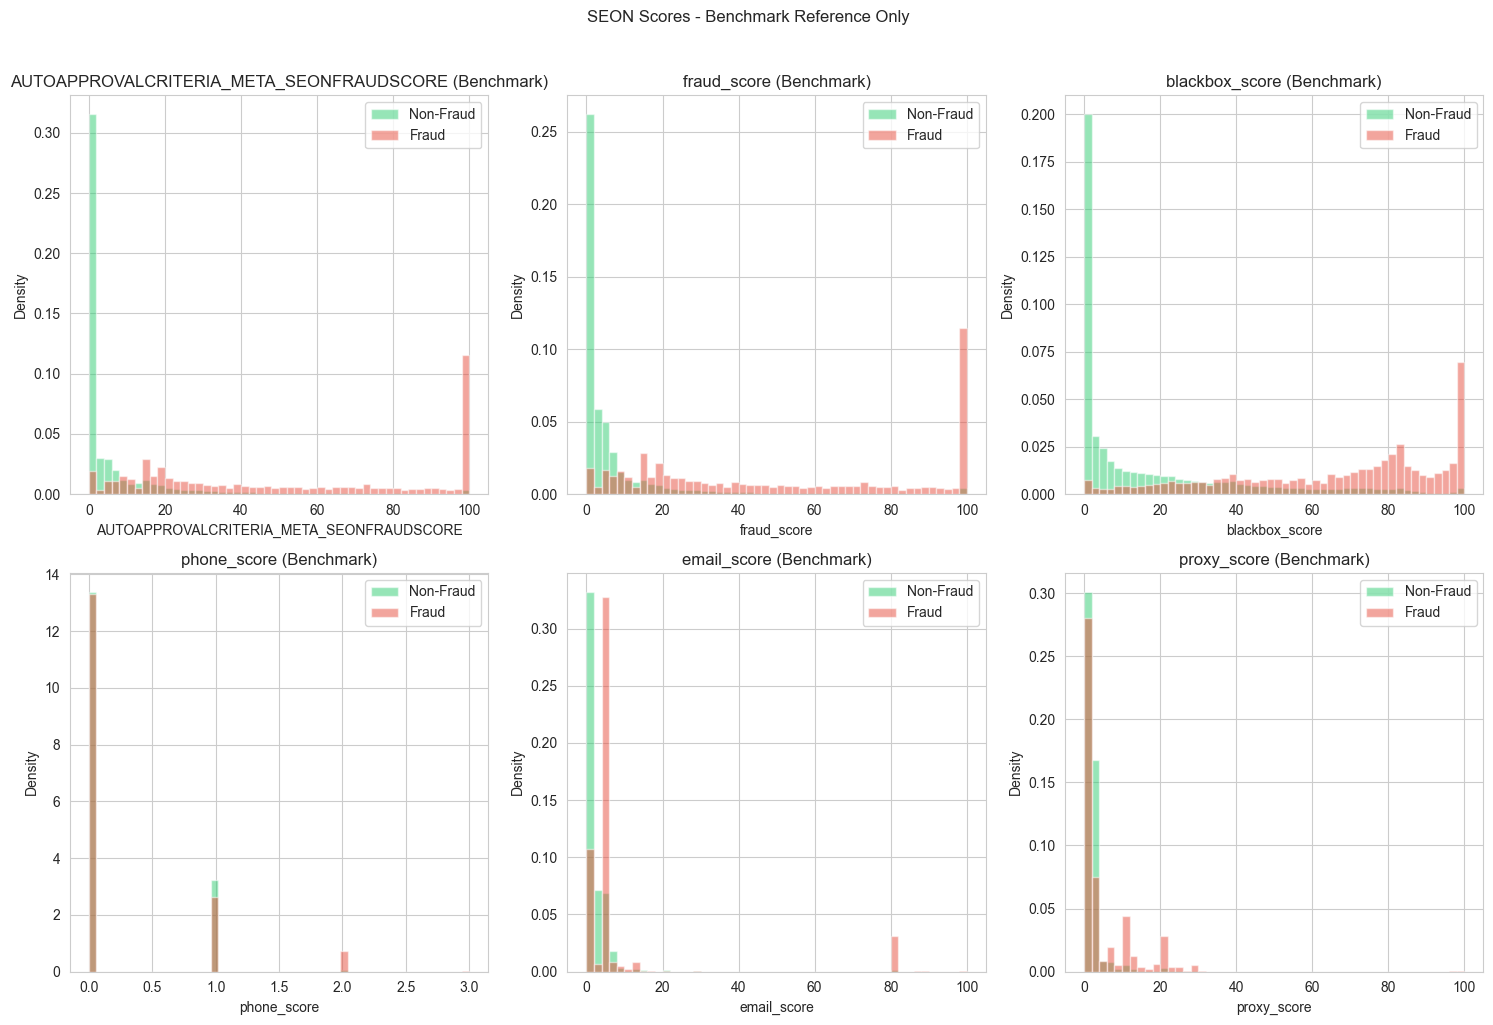

In [16]:
# Analyze SEON score distributions by fraud status (REFERENCE ONLY - not used as features)
# Load scores from original sample for visualization
benchmark_score_cols = [c for c in score_cols if c in df_sample.columns]

if benchmark_score_cols:
    print("SEON Scores (Benchmark Reference - NOT used as model features):")
    
    # Get scores from original dataframe
    score_data = df_sample.select(benchmark_score_cols + [TARGET_COL]).to_pandas()
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, col in enumerate(benchmark_score_cols[:6]):
        ax = axes[i]
        
        # Get data for plotting
        fraud_vals = score_data[score_data[TARGET_COL] == 1][col].dropna()
        non_fraud_vals = score_data[score_data[TARGET_COL] == 0][col].dropna()
        
        # Plot histograms
        ax.hist(non_fraud_vals, bins=50, alpha=0.5, label="Non-Fraud", color="#2ecc71", density=True)
        ax.hist(fraud_vals, bins=50, alpha=0.5, label="Fraud", color="#e74c3c", density=True)
        ax.set_xlabel(col)
        ax.set_ylabel("Density")
        ax.set_title(f"{col} (Benchmark)")
        ax.legend()
    
    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle("SEON Scores - Benchmark Reference Only", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No SEON score columns found for benchmark visualization.")

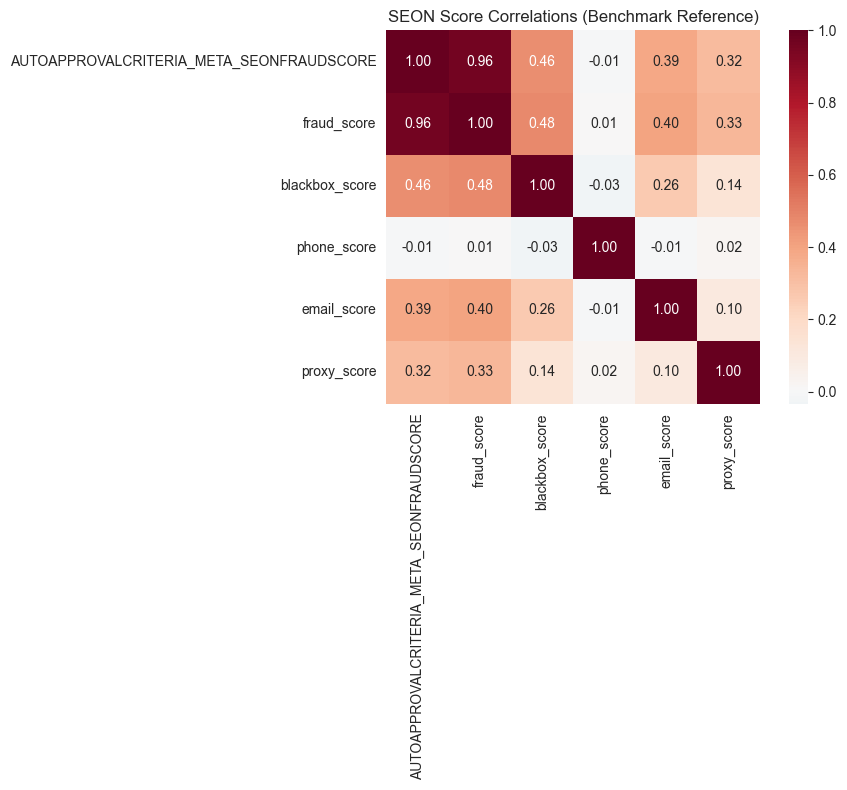

In [17]:
# Correlation matrix of SEON score features (REFERENCE ONLY)
if len(benchmark_score_cols) > 1:
    score_corr = score_data[benchmark_score_cols].corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        score_corr, 
        annot=True, 
        cmap="RdBu_r", 
        center=0, 
        fmt=".2f",
        ax=ax,
        square=True
    )
    ax.set_title("SEON Score Correlations (Benchmark Reference)")
    plt.tight_layout()
    plt.show()

## 6. Summary and Insights

In [18]:
# Compile key findings
print("="*60)
print("KEY FINDINGS")
print("="*60)
print("\n⚠️  SEON scores EXCLUDED from features (benchmark only)")

print("\n1. Cluster Analysis (using non-score features):")
high_fraud_clusters = cluster_fraud[cluster_fraud["fraud_rate"] > df_features[TARGET_COL].mean() * 1.5]
print(f"   - {len(high_fraud_clusters)} clusters with >1.5x average fraud rate")
if len(high_fraud_clusters) > 0:
    print(f"   - Highest fraud rate cluster: {high_fraud_clusters.index[0]} ({high_fraud_clusters['fraud_rate'].iloc[0]:.2%})")

print("\n2. Top Predictive Features (non-score):")
for i, (_, row) in enumerate(importances.head(5).iterrows()):
    print(f"   {i+1}. {row['feature']}: {row['importance']:.4f}")

print("\n3. Model Performance (without SEON scores):")
print(f"   - Random Forest ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"   - Logistic Regression ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

print("\n4. SEON Benchmark Reference (for comparison):")
if benchmark_score_cols:
    for col in benchmark_score_cols[:3]:
        fraud_mean = score_data[score_data[TARGET_COL] == 1][col].mean()
        non_fraud_mean = score_data[score_data[TARGET_COL] == 0][col].mean()
        print(f"   - {col}: Fraud avg={fraud_mean:.2f}, Non-fraud avg={non_fraud_mean:.2f}")

print("="*60)

KEY FINDINGS

⚠️  SEON scores EXCLUDED from features (benchmark only)

1. Cluster Analysis (using non-score features):
   - 3 clusters with >1.5x average fraud rate
   - Highest fraud rate cluster: 3 (67.72%)

2. Top Predictive Features (non-score):
   1. AUTOAPPROVALCRITERIA_CRITERIA_SEONAPPROVED: 0.2276
   2. LISTING_LEGACY_PPAPERSONID: 0.1007
   3. LISTING_LEGACY_PERSONID: 0.0901
   4. VERSION: 0.0859
   5. email/haveibeenpwned_listed: 0.0603

3. Model Performance (without SEON scores):
   - Random Forest ROC-AUC: 0.9541
   - Logistic Regression ROC-AUC: 0.7651

4. SEON Benchmark Reference (for comparison):
   - AUTOAPPROVALCRITERIA_META_SEONFRAUDSCORE: Fraud avg=51.50, Non-fraud avg=6.48
   - fraud_score: Fraud avg=51.14, Non-fraud avg=6.71
   - blackbox_score: Fraud avg=65.86, Non-fraud avg=18.02
